# Introduction : objectives

This notebook includes supplementary work on ICOS datasets carried out during my internship. As it was not used in the final report, it remained unfinished and messy. Furthermore, these are fragments of code and some of them are not directly executable, but feel free to reuse and adapt them as you see fit.

# Importation of packages and modules

In [16]:
# In the module "data_preparation" of the Scripts folder, the specific function dominant_wind isolates prevailing winds based on their direction
# So let's import data_preparation and other useful packages
import sys
sys.path.append('C:/Users/alise/myproject/ICOS-M2-internship-alise/scripts')

import data_preparation as datprep
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Polygon
from pyproj import Transformer
from matplotlib import pyplot as plt
import contextily as cx
import seaborn as sns
from statsmodels.formula.api import ols
from scipy.fft import fft, ifft

# 1) Isolate prevailing winds

The Kljun footprint climatology function is based on a smoothed average of all single footprints. Therefore for a given period, the resulting climatology may not be representative of a wind sector. For example, the area contributing to the footprint can be smaller for one (or more) prevailing wind direction. So it is interesting to isolate timestamps with prevailing wind directions and to plot the associated footprint climatologies to see the raw extent of the footprint.

In [7]:
# Data importation
flux_NDVI = pd.read_csv('C:/Users/alise/myproject/ICOS-M2-internship-alise/data_plots/flux_NDVI.csv')
flux_NDVI["TIMESTAMP_START"] = pd.to_datetime(flux_NDVI["TIMESTAMP_START"])

In [8]:
# Select 2020-2024 data (a lot of missing data for 2019)
flux_NDVI = flux_NDVI[flux_NDVI['TIMESTAMP_START'] >= '2020-01-01']

## Example for growth/day-time

In [ ]:
# Select only the data of vegetation growth and day-time
flux_data_growth_day = flux_NDVI.loc[(flux_NDVI['phase_label']=='Growth') & (flux_data_growth['Night']==False) , :]

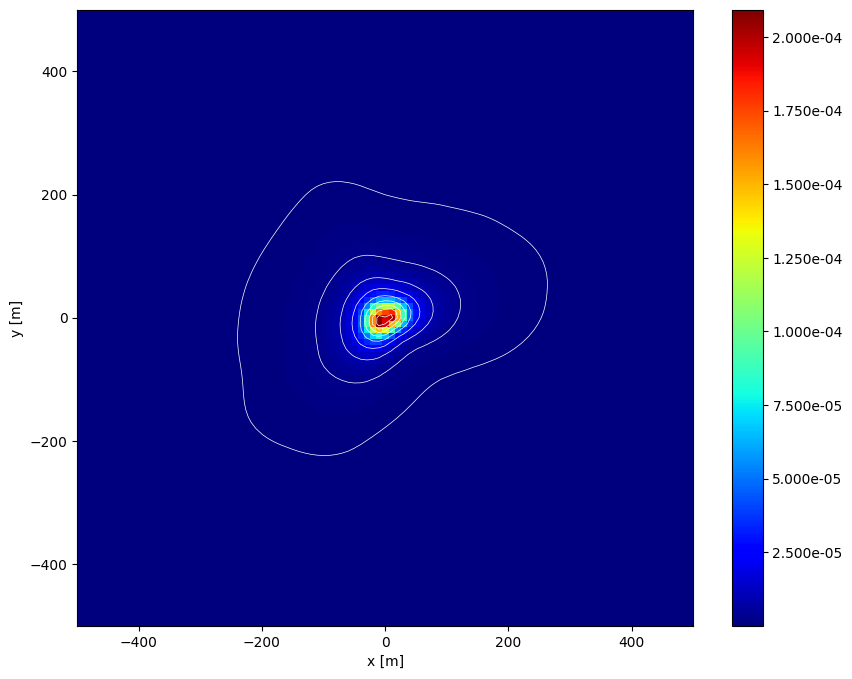

In [ ]:
# Calculate and plot the footprint climatology
import footprint_analysis as FFP_analys
import calc_footprint_FFP_climatology as myfootprint_climato

inputs = FFP_analys.extract_FFP_inputs(flux_data_growth_day)
FFP_climato_growth_day = myfootprint_climato.FFP_climatology(
        zm=inputs['zmt'].tolist(),
        z0=inputs['z0t'],
        umean=inputs['umeant'].tolist(),
        h=inputs['ht'].tolist(),
        ol=inputs['olt'].tolist(),
        sigmav=inputs['sigmavt'].tolist(),
        ustar=inputs['ustart'].tolist(),
        wind_dir=inputs['wind_dirt'].tolist(),
        domain=[-500., 500., -500., 500.],
        dx=10,
        dy=10,
        rs=[10,20,30,40,50,60,70,80,90],
        verbosity=0,
        fig=1
    )

### Isolate prevailing winds and plot the footprint climatology

In [ ]:
# The dominant_wind function returns only the dominant wind(s) ligns from the input dataframe and print the prevailing wind(s) directions and frequencies
flux_data_growth_day_dom = datprep.dominant_wind(flux_data_growth_day, 'WD_2_1_1')

The prevailing winds are: SW
wind_sector
N     0.091852
NE    0.135913
E     0.184054
SE    0.030307
S     0.074834
SW    0.215993
W     0.139177
NW    0.127870
Name: proportion, dtype: float64


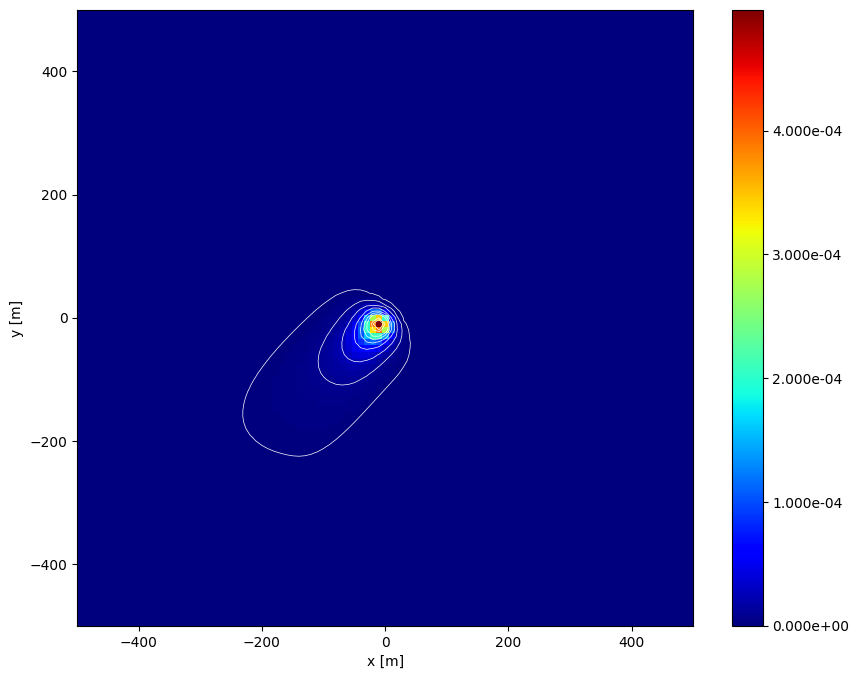

In [26]:
#Footprint for SW wind
flux_data_growth_day_SW = flux_data_growth_day_dom.loc[flux_data_growth_day_dom['wind_sector']=='SW', :]

inputs = FFP_analys.extract_FFP_inputs(flux_data_growth_day_SW)
FFP_climato_growth_day_SW = myfootprint_climato.FFP_climatology(
        zm=inputs['zmt'].tolist(),
        z0=inputs['z0t'],
        umean=inputs['umeant'].tolist(),
        h=inputs['ht'].tolist(),
        ol=inputs['olt'].tolist(),
        sigmav=inputs['sigmavt'].tolist(),
        ustar=inputs['ustart'].tolist(),
        wind_dir=inputs['wind_dirt'].tolist(),
        domain=[-500., 500., -500., 500.],
        dx=10,
        dy=10,
        rs=[10,20,30,40,50,60,70,80,90],
        verbosity=0,
        fig=1
    )

## Compare the footprint climatologies extent on a map (IGN)

In [27]:
# Set tower coordinates (longitude and latitude in WGS84, EPSG : 4326)
lon_tower = 6.410519
lat_tower = 45.041375

In [44]:
# Define a function that extracts and converts to latitude and longitude the coordinates for each r (percentage of source area)
def coordinates_extract(data_FFP, lon_tower, lat_tower) :

    x0, y0 = FFP_analys.transform_coordinates(lon_tower, lat_tower, crs_in = "EPSG:4326", crs_out = "EPSG:32631")

    rs_array = np.array(data_FFP['rs'])
    xr_all = data_FFP['xr']
    yr_all = data_FFP['yr']
    
    contours = {}
    for i, r in enumerate(rs_array):
        try:
            xr = np.array(xr_all[i])
            yr = np.array(yr_all[i])
            xcoord = x0 + xr
            ycoord = y0 + yr

            lon, lat = FFP_analys.transform_coordinates(xcoord, ycoord, crs_in = "EPSG:32631", crs_out = "EPSG:4326")
            contours[r] = (lon, lat)
        except IndexError:
            print(f"Missing {r*100:.0f}% contour.")
    
    return contours

In [46]:
# Extract contours coordinates (longitudes and latitudes) for Growth/Day and for SW prevailing wind
coord_growth_day = coordinates_extract(FFP_climato_growth_day, lon_tower, lat_tower) 
coord_growth_day_SW = coordinates_extract(FFP_climato_growth_day_SW, lon_tower, lat_tower) 

In [48]:
# Create a function to convert each contour into polygon
def contours_to_gdf(contours_dict, crs="EPSG:4326"):
    polygons = []
    labels = []
    for label, (lon, lat) in contours_dict.items():
        poly = Polygon(zip(lon, lat))
        polygons.append(poly)
        labels.append(label)
    gdf = gpd.GeoDataFrame({'label': labels, 'geometry': polygons}, crs=crs)
    return gdf

In [50]:
# Apply the function to convert into GDF for Growth/Day and for SW prevailing wind
contours_gdf_growth_day = contours_to_gdf(coord_growth_day)
contours_gdf_growth_day_SW = contours_to_gdf(coord_growth_day_SW)

In [55]:
# Create a coordinate converter to project into the coordinate system of the MNT
transform_to_mnt_crs = Transformer.from_crs("EPSG:4326", "EPSG:32631", always_xy=True)

# Coordinates of the ICOS station
x0_conv, y0_conv = transform_to_mnt_crs.transform(lon_tower, lat_tower)
contours_gdf_growth_day_crs = contours_gdf_growth_day.to_crs("EPSG:32631")
contours_gdf_growth_day_SW_crs = contours_gdf_growth_day_SW.to_crs("EPSG:32631")

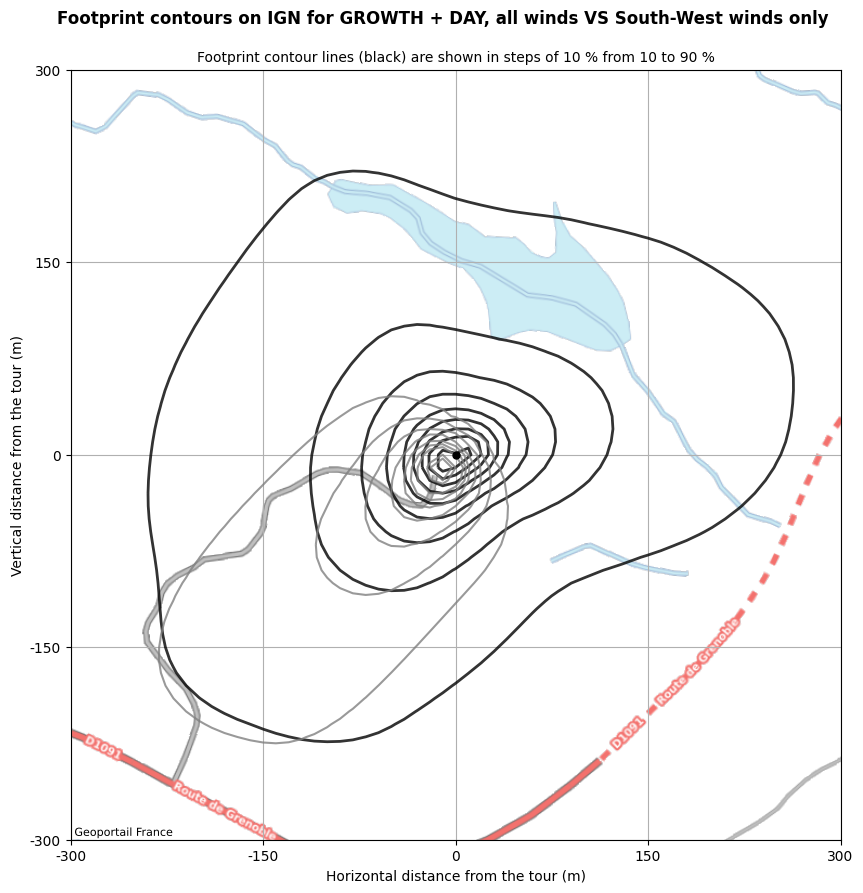

In [65]:
# Do a map to compare 2 footprints (global and just SW wind footprint)
domain_size = 300 # Limits of the map

fig, ax = plt.subplots(figsize=(10, 10))

# Conversion of axes coordinates (center on the tour)
x_extent = np.array([x0_conv - domain_size, x0_conv + domain_size])
y_extent = np.array([y0_conv - domain_size, y0_conv + domain_size])
ax.set_xlim(x_extent)
ax.set_ylim(y_extent)

# Add contours for global footprint
contours_gdf_growth_day_crs.boundary.plot(ax=ax, edgecolor="black", linewidth=2, alpha=0.8)

# Add contours for SW wind
contours_gdf_growth_day_SW_crs.boundary.plot(ax=ax, edgecolor="grey", linewidth=1.5, alpha=0.8)

# Add the station localization
ax.plot(x0_conv, y0_conv, marker="o", color="black", markersize=5)

# Add hydrography background
cx.add_basemap(ax, crs="EPSG:32631", source=cx.providers.GeoportailFrance.Hydrography_Hydrography, alpha=0.6)

# Add road background
cx.add_basemap(ax, crs="EPSG:32631", source=cx.providers.GeoportailFrance.Transportnetworks_Roads, alpha=0.6)

# Axes scaling (meters from the tour)
ax.set_xticks(np.linspace(x_extent[0], x_extent[1], 5))
ax.set_yticks(np.linspace(y_extent[0], y_extent[1], 5))
ax.set_xticklabels([int(x - x0_conv) for x in np.linspace(x_extent[0], x_extent[1], 5)])
ax.set_yticklabels([int(y - y0_conv) for y in np.linspace(y_extent[0], y_extent[1], 5)])

# Add a grid
plt.grid(True)

ax.set_xlabel("Horizontal distance from the tour (m)")
ax.set_ylabel("Vertical distance from the tour (m)")
plt.suptitle("Footprint contours on IGN for GROWTH + DAY, all winds VS South-West winds only", y= 0.94, size = 'large', weight = 'bold')
plt.title("Footprint contour lines (black) are shown in steps of 10 % from 10 to 90 %", size = 'medium')

plt.show()

As expected, the Kljun FFP climatology function smooths the extent of the footprint. So in this example, with all the timestamps related to growth and day-time as inputs, it returns an overview of the area contributing to the footprint. But if we isolate the prevailing winds, then we find that the area is bigger as it is not influenced by other wind directions. It would be interesting to check the difference with stronger wind directions (speed), and not just higher frequencies.

# 2) Calculate a seasonal cycle of CO2 

The goal of the following code is to estimate seasonal cycles of CO2 flux using the curve fitting procedure described in _“The fingerprint of the summer 2018 drought in Europe on ground-based atmospheric CO2 measurements”, Ramonet M et al., 2020, Phil. Trans. R. Soc. B 375_. "The CO2 time series are fitted with a 4-harmonics curve and a quadratic polynomial function. Residuals from this fit are filtered in the time domain using a low-pass filter in order to separate high-frequency variations and inter-annual variabilities."

In [8]:
# Open the filtered data
filtered_data = pd.read_csv('C:/Users/alise/myproject/ICOS-M2-internship-alise/data_plots/filtered_data.csv')
filtered_data["TIMESTAMP_START"] = pd.to_datetime(filtered_data["TIMESTAMP_START"])

In [9]:
# Add year and DOY columns
filtered_data['year'] = filtered_data['TIMESTAMP_START'].dt.year
filtered_data['DOY'] = filtered_data['TIMESTAMP_START'].dt.dayofyear

In [10]:
# Resample by day, calculate a daily average
filtered_data['DATE'] = pd.to_datetime(filtered_data['TIMESTAMP_START'])
filtered_data = filtered_data.set_index('DATE')
filtered_data['FC_day_mean'] = filtered_data['FC_1_1_1'].resample('D').mean()

In [12]:
# Delete NaN
filtered_data = filtered_data.dropna(subset = ['FC_day_mean'])

<Axes: xlabel='TIMESTAMP_START'>

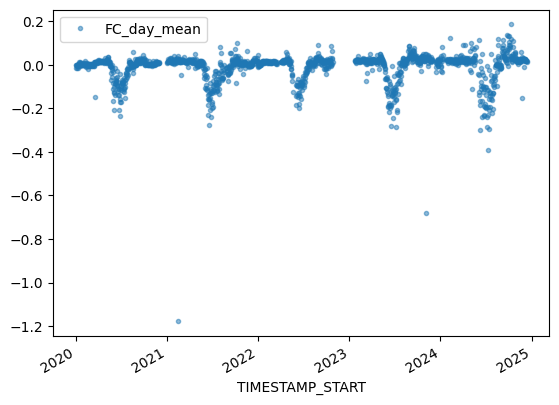

In [ ]:
# Quick plot
filtered_data.plot(x='TIMESTAMP_START', y='FC_day_mean', style='.', alpha=0.5)

This graph illustrates the daily averages of carbon fluxes from 2020 to 2024.

In [14]:
# Add the 4 harmonic composants
filtered_data['sin1'] = np.sin(2 * np.pi * filtered_data['DOY'] / 365)
filtered_data['cos1'] = np.cos(2 * np.pi * filtered_data['DOY'] / 365)
filtered_data['sin2'] = np.sin(4 * np.pi * filtered_data['DOY'] / 365)
filtered_data['cos2'] = np.cos(4 * np.pi * filtered_data['DOY'] / 365)
filtered_data['sin3'] = np.sin(6 * np.pi * filtered_data['DOY'] / 365)
filtered_data['cos3'] = np.cos(6 * np.pi * filtered_data['DOY'] / 365)
filtered_data['sin4'] = np.sin(8 * np.pi * filtered_data['DOY'] / 365)
filtered_data['cos4'] = np.cos(8 * np.pi * filtered_data['DOY'] / 365)

In [ ]:
# Adjust a model with a quadratic polynomial function and harmonic composants
formula = 'FC_day_mean ~ year + I(year**2) + sin1 + cos1 + sin2 + cos2 + sin3 + cos3 + sin4 + cos4'
model = ols(formula, data=filtered_data).fit()

In [18]:
# Calculate the predicted values and the residuals
filtered_data['FC_fitted'] = model.predict(filtered_data)
filtered_data['residuals'] = filtered_data['FC_day_mean'] - filtered_data['FC_fitted']

In [27]:
filtered_data['DATE'] = pd.to_datetime(filtered_data['TIMESTAMP_START'])

# Residuals are filtered using a low-pass filter
nee_fft = fft(filtered_data['residuals'])
nee_fft[50:] = 0  
filtered_data['filtered_residuals'] = np.real(ifft(nee_fft))

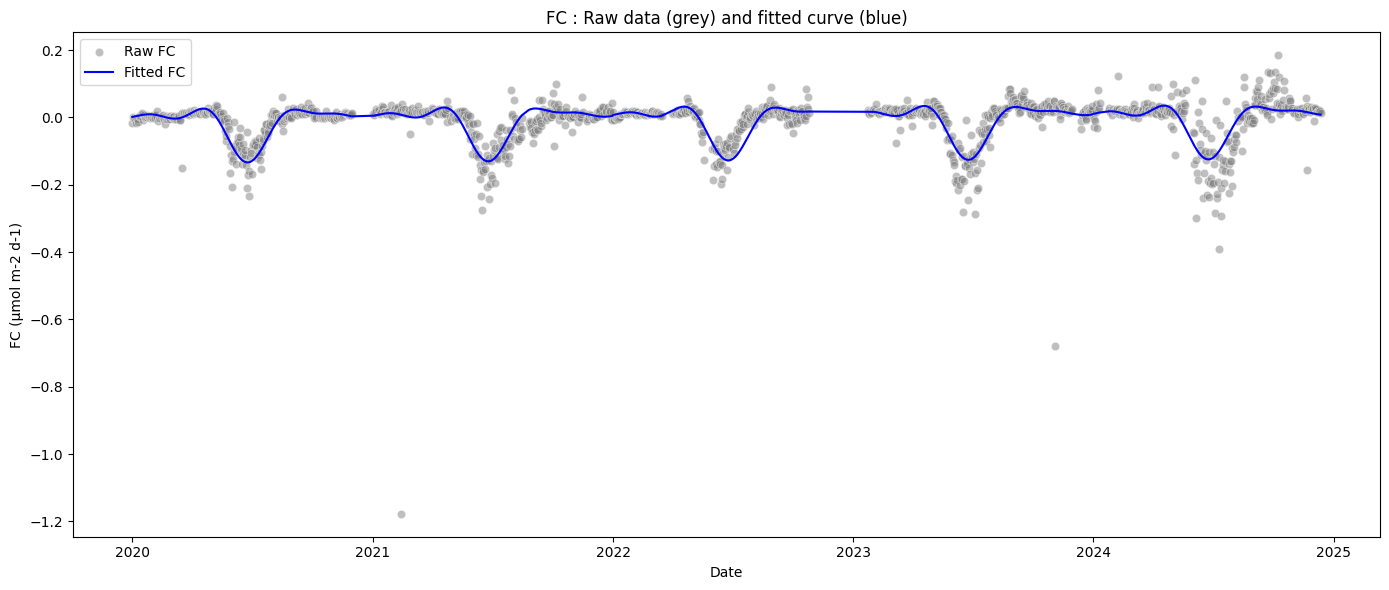

In [31]:
# Plot raw VS fitted data
plt.figure(figsize=(14, 6))
sns.scatterplot(x='DATE', y='FC_day_mean', data=filtered_data, color='gray', alpha=0.5, label='Raw FC')
sns.lineplot(x='DATE', y='FC_fitted', data=filtered_data, color='blue', label='Fitted FC')
plt.xlabel("Date")
plt.ylabel("FC (µmol m-2 d-1)")
plt.title("FC : Raw data (grey) and fitted curve (blue)")
plt.legend()
plt.tight_layout()
plt.show()

This graph shows the smoothed carbon fluxes obtained with the curve fitting procedure (4-harmonics curve and quadratic polynomial function). Visually the predicted values seem consistent with the raw carbon fluxes.

In [36]:
filtered_data['FC_day_mean'].max()

np.float64(0.18488151899999997)

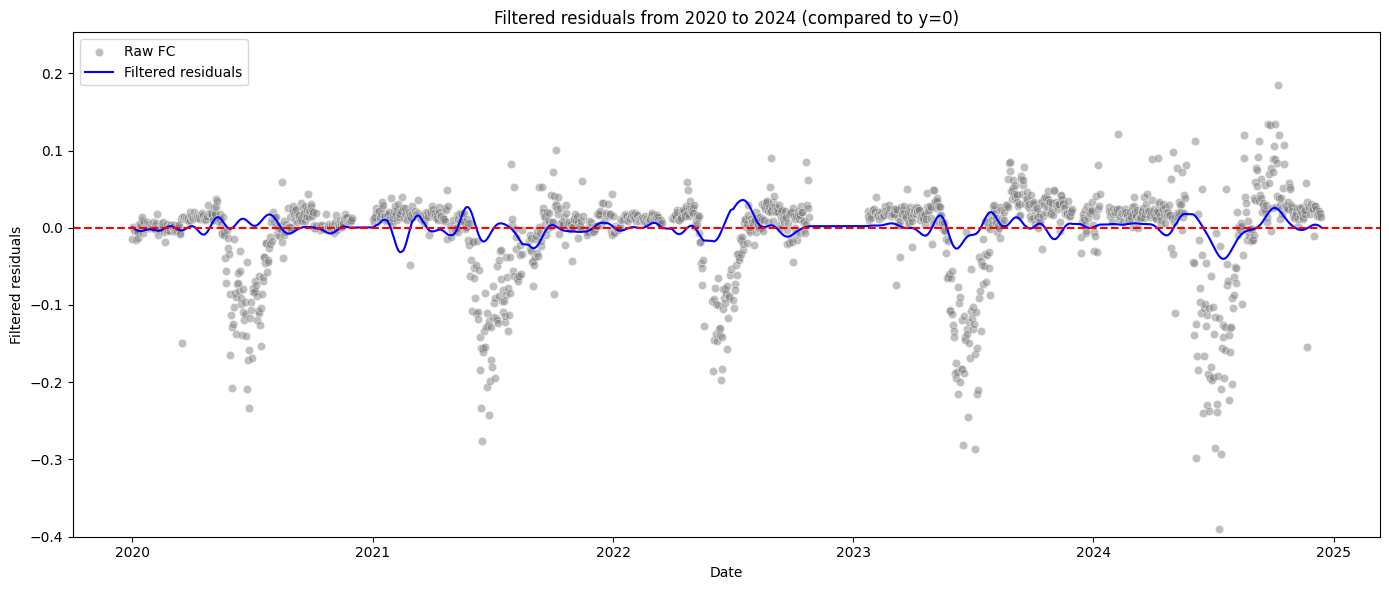

In [42]:
# Plot filtered residuals (inter-annual variabilities)
plt.figure(figsize=(14, 6))
sns.scatterplot(x='DATE', y='FC_day_mean', data=filtered_data, color='gray', alpha=0.5, label='Raw FC')
plt.plot(filtered_data['DATE'],filtered_data['filtered_residuals'], data=filtered_data, color='blue', label='Filtered residuals')
plt.axhline(y=0, color = 'red', linestyle = 'dashed')
plt.ylim(bottom = -0.4)
plt.xlabel("Date")
plt.ylabel("Filtered residuals")
plt.title("Filtered residuals from 2020 to 2024 (compared to y=0)")
plt.legend()
plt.tight_layout()
plt.show()

Filtered low frequencies of the residuals from the curve fitting procedure are illustrated in this graph. We can see that low-frequency variations, assumed to represent inter-annual variabilities, are more important (further from y = 0) for one period in 2022 and one in 2024. During summer 2022, carbon fluxes are higher than expected, maybe due to the drought. Conversely, 2024 is characterized by significant snowfall and during the summer of that year, carbon fluxes are lower than predicted by the model.

# 3) Cyclic analysis